# 01. Exploratory Data Analysis

First contact with the Expedia personalised hotel ranking data. The aim of this notebook is to find out what kind of object we are actually dealing with: how big the files are, what the rows mean, what the targets look like, where the missing values live, and where the obvious traps are.

I am going to read the raw CSVs straight from `data/raw/` and refuse to make any modelling decisions yet. Cleaning happens in notebook 02.

In [1]:
import gc
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
FIG_DIR = PROJECT_ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = RAW_DIR / "training_set_VU_DM.csv"
TEST_PATH = RAW_DIR / "test_set_VU_DM.csv"

assert TRAIN_PATH.exists(), f"Missing {TRAIN_PATH}"
assert TEST_PATH.exists(), f"Missing {TEST_PATH}"

print(f"train file: {TRAIN_PATH.stat().st_size / 1e9:.2f} GB")
print(f"test  file: {TEST_PATH.stat().st_size / 1e9:.2f} GB")


def rss_gb():
    return psutil.Process(os.getpid()).memory_info().rss / 1e9


print(f"baseline RSS: {rss_gb():.2f} GB")

sns.set_theme(style="whitegrid", context="notebook")

train file: 1.27 GB
test  file: 1.21 GB
baseline RSS: 0.25 GB


Both files are roughly 1.2 GB on disk, so reading them into a pandas DataFrame without any tricks will cost a few GB of RAM. Worth keeping an eye on.

## Schema sniff

Before reading the full file I just want to see the columns and a few rows. CSV parsing with default dtypes turns every integer column with a missing value into a float, which is a footgun if I am not paying attention.

In [2]:
schema_train = pd.read_csv(TRAIN_PATH, nrows=2000)
schema_test = pd.read_csv(TEST_PATH, nrows=2000)

print(f"train columns ({len(schema_train.columns)}):")
print(list(schema_train.columns))
print()
print(f"test columns ({len(schema_test.columns)}):")
print(list(schema_test.columns))
print()
print("columns in train but NOT in test:")
print(sorted(set(schema_train.columns) - set(schema_test.columns)))

train columns (54):
['srch_id', 'date_time', 'site_id', 'visitor_location_country_id', 'visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_country_id', 'prop_id', 'prop_starrating', 'prop_review_score', 'prop_brand_bool', 'prop_location_score1', 'prop_location_score2', 'prop_log_historical_price', 'position', 'price_usd', 'promotion_flag', 'srch_destination_id', 'srch_length_of_stay', 'srch_booking_window', 'srch_adults_count', 'srch_children_count', 'srch_room_count', 'srch_saturday_night_bool', 'srch_query_affinity_score', 'orig_destination_distance', 'random_bool', 'comp1_rate', 'comp1_inv', 'comp1_rate_percent_diff', 'comp2_rate', 'comp2_inv', 'comp2_rate_percent_diff', 'comp3_rate', 'comp3_inv', 'comp3_rate_percent_diff', 'comp4_rate', 'comp4_inv', 'comp4_rate_percent_diff', 'comp5_rate', 'comp5_inv', 'comp5_rate_percent_diff', 'comp6_rate', 'comp6_inv', 'comp6_rate_percent_diff', 'comp7_rate', 'comp7_inv', 'comp7_rate_percent_diff', 'comp8_rate', 'comp8_inv', 'comp8_rate_per

Train has four extra columns: `booking_bool`, `click_bool`, `gross_bookings_usd`, and `position`. The first two are the targets. `gross_bookings_usd` is only set when a booking happened so it is target-derived. `position` is the rank Expedia itself put the hotel at and obviously cannot be used at predict time. Anything in this list has to be dropped before feeding the model.

In [3]:
schema_train.dtypes.to_frame("dtype").assign(sample=schema_train.iloc[0]).head(60)

,dtype,sample
srch_id,int64,1
date_time,str,2013-04-04 08:32:15
site_id,int64,12
visitor_location_country_id,int64,187
visitor_hist_starrating,float64,NaN
visitor_hist_adr_usd,float64,NaN
prop_country_id,int64,219
prop_id,int64,893
prop_starrating,int64,3
prop_review_score,float64,3.5


A few notes from the dtype table:

- `date_time` is an object/string. If we want time features we will have to parse it ourselves.
- All the `comp*_rate`, `comp*_inv` and `comp*_rate_percent_diff` columns are floats with a lot of NaNs, even in the first sampled row. We will quantify that below.
- `srch_query_affinity_score` and `orig_destination_distance` are also frequently NaN.
- `visitor_hist_starrating` and `visitor_hist_adr_usd` are only filled when the user has booking history, which from the row above is also NaN.

## Full load

Now the real read. With 5M rows I want to be careful: I let pandas pick types and then we see how much memory that costs.

In [4]:
t0 = time.time()
train = pd.read_csv(TRAIN_PATH)
print(f"train loaded in {time.time() - t0:.1f}s, RSS {rss_gb():.2f} GB")
print(f"train shape: {train.shape}")

train loaded in 7.5s, RSS 4.05 GB
train shape: (4958347, 54)


In [5]:
t0 = time.time()
test = pd.read_csv(TEST_PATH)
print(f"test loaded in {time.time() - t0:.1f}s, RSS {rss_gb():.2f} GB")
print(f"test shape: {test.shape}")

test loaded in 6.1s, RSS 5.21 GB
test shape: (4959183, 50)


In [6]:
mem_train_gb = train.memory_usage(deep=True).sum() / 1e9
mem_test_gb = test.memory_usage(deep=True).sum() / 1e9
print(f"train in memory: {mem_train_gb:.2f} GB")
print(f"test  in memory: {mem_test_gb:.2f} GB")
print(f"total RSS now : {rss_gb():.2f} GB")

train in memory: 2.24 GB
test  in memory: 2.08 GB
total RSS now : 5.22 GB


Roughly 4.96M train rows and 4.96M test rows, almost the same number. Train costs about 2.2 GB in memory and test 2.1 GB; with both loaded we sit around 5 GB RSS. There is plenty of headroom on this machine, but it is enough that I will think about dtype downcasting when the cleaning step runs (notebook 02).

## Row layout

Let me look at one search result page in full so I can see what a row really represents.

In [7]:
example_id = train["srch_id"].iloc[0]
example_block = train[train["srch_id"] == example_id]
print(f"srch_id {example_id} has {len(example_block)} rows, {example_block['prop_id'].nunique()} unique prop_ids")
example_block.head(10)

srch_id 1 has 28 rows, 28 unique prop_ids


,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,893,3,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,10404,4,4.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,21315,3,4.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,27348,2,4.0,...,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,29604,4,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
5,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,30184,4,4.5,...,NaN,NaN,NaN,NaN,0.0,0.0,7.0,0,NaN,0
6,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,44147,3,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
7,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,50984,2,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0
8,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,53341,4,4.0,...,NaN,NaN,NaN,NaN,0.0,0.0,6.0,0,NaN,0
9,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,56880,4,4.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


So one row is one (search query, hotel) pair. The 28 rows for `srch_id=1` show 28 distinct `prop_id` values, meaning each hotel appears once per search. That is the ranking unit. Same `date_time`, `site_id`, `visitor_*` columns repeat across the page, so those are query-level rather than hotel-level features.

## Target columns

The train-only columns are the targets and a couple of leakage variables. Let me confirm distributions.

In [8]:
target_cols = ["click_bool", "booking_bool", "gross_bookings_usd", "position"]
for col in target_cols:
    if col in train.columns:
        print(f"{col}: dtype={train[col].dtype}, "
              f"missing={train[col].isna().mean():.4f}, "
              f"mean={train[col].mean(skipna=True):.4f}")

click_bool: dtype=int64, missing=0.0000, mean=0.0447
booking_bool: dtype=int64, missing=0.0000, mean=0.0279
gross_bookings_usd: dtype=float64, missing=0.9721, mean=386.2833
position: dtype=int64, missing=0.0000, mean=16.8562


A click on average happens for 4.5% of rows and a booking for 2.8%. `gross_bookings_usd` is missing 97% of the time, which lines up with the booking rate; only the booked rows have a price. `position` has no missing values and averages 16.9, matching a typical 30-row search page.

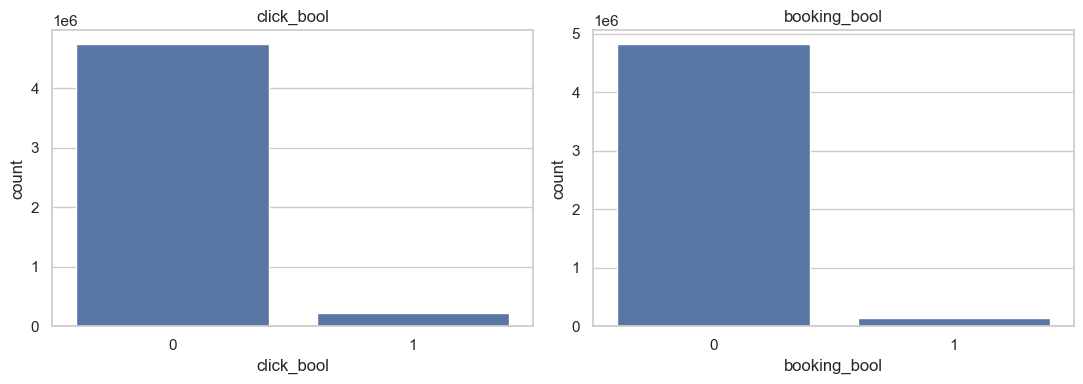

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="click_bool", data=train, ax=axes[0])
axes[0].set_title("click_bool")
sns.countplot(x="booking_bool", data=train, ax=axes[1])
axes[1].set_title("booking_bool")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_click_book_counts.png", dpi=110)
plt.show()

In [10]:
click_rate = train["click_bool"].mean()
book_rate = train["booking_bool"].mean()
print(f"click rate: {click_rate:.4f}  ({click_rate * 100:.2f}%)")
print(f"book  rate: {book_rate:.4f}  ({book_rate * 100:.2f}%)")
print(f"book | click: {(train['booking_bool'].sum() / max(train['click_bool'].sum(), 1)):.4f}")

click rate: 0.0447  (4.47%)
book  rate: 0.0279  (2.79%)
book | click: 0.6237


A book is rarer than a click and rare overall. The conditional rate `P(book | click) = 0.62` is striking: when a user clicks, they end up booking 62% of the time. That makes click and book very tightly coupled. For a learning-to-rank objective the natural relevance encoding is `relevance = 5*book + 1*click_only`, where `click_only` means clicked but not booked, so the grades stay 0, 1, 5 without double-counting.

In [11]:
relevance = 5 * train["booking_bool"] + 1 * (train["click_bool"] & ~train["booking_bool"].astype(bool))
print("relevance value counts:")
print(relevance.value_counts())
print(f"share of zero-relevance rows: {(relevance == 0).mean():.4f}")
del relevance
gc.collect()

relevance value counts:
0    4736468
5     138390
1      83489
Name: count, dtype: int64
share of zero-relevance rows: 0.9553


788

The label distribution: 4.74M rows with relevance 0, 138k booked (rel=5), and 83k click-only (rel=1). Almost 96% of rows carry no positive signal at all. That is normal for click-through ranking but it does mean we cannot rely on pointwise prediction; the model has to learn within-query contrasts.

## Search-page sizes

How many hotels does a typical search show? This sets the scale for ranking.

queries: 199,795
min=5, median=29.0, mean=24.8, max=38


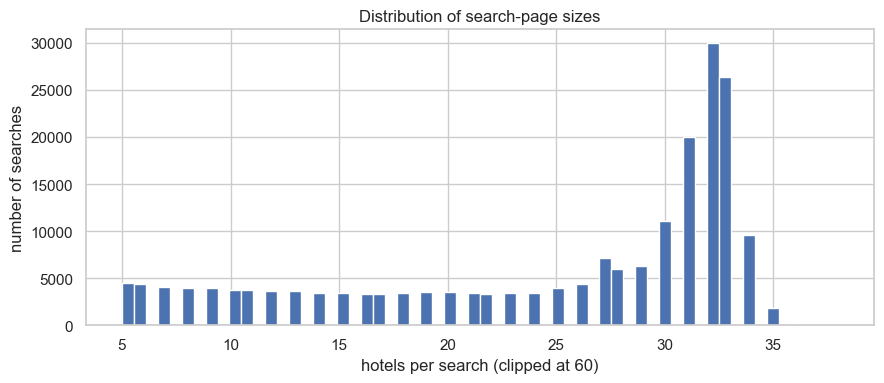

In [12]:
group_sizes = train.groupby("srch_id").size()
print(f"queries: {len(group_sizes):,}")
print(f"min={group_sizes.min()}, median={group_sizes.median()}, "
      f"mean={group_sizes.mean():.1f}, max={group_sizes.max()}")

fig, ax = plt.subplots(figsize=(9, 4))
group_sizes.clip(upper=60).hist(bins=60, ax=ax)
ax.set_xlabel("hotels per search (clipped at 60)")
ax.set_ylabel("number of searches")
ax.set_title("Distribution of search-page sizes")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_group_sizes.png", dpi=110)
plt.show()

199,795 searches in the training set. The histogram is bimodal looking: a flat plateau from 5 to about 25 hotels per page (each bucket holds roughly 3 to 5 thousand searches), and then a sharp spike near 32 holding about 30k searches. 32 is clearly the default page size, with smaller pages being the tail. Max is 38, min is 5. NDCG@5 will mostly evaluate the top 5 of these, so the size doesn't matter a lot for the metric, but the group structure does matter for splitting and for ranker batching: I have to keep all rows for a `srch_id` together when building train and validation folds.

## Missingness

Many of these columns are documented as optional. Let me see who is missing what.

In [13]:
miss = train.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
print(f"{len(miss)} columns with at least one missing value")
miss.head(20)

31 columns with at least one missing value


comp1_rate_percent_diff      0.980954
comp6_rate_percent_diff      0.980604
comp1_rate                   0.975813
comp1_inv                    0.973871
comp4_rate_percent_diff      0.973563
gross_bookings_usd           0.972089
comp7_rate_percent_diff      0.972064
comp6_rate                   0.951565
visitor_hist_starrating      0.949204
visitor_hist_adr_usd         0.948977
comp6_inv                    0.947366
comp4_rate                   0.938008
comp7_rate                   0.936401
srch_query_affinity_score    0.935986
comp4_inv                    0.930690
comp7_inv                    0.928117
comp3_rate_percent_diff      0.904646
comp2_rate_percent_diff      0.887818
comp8_rate_percent_diff      0.876021
comp5_rate_percent_diff      0.830367
dtype: float64

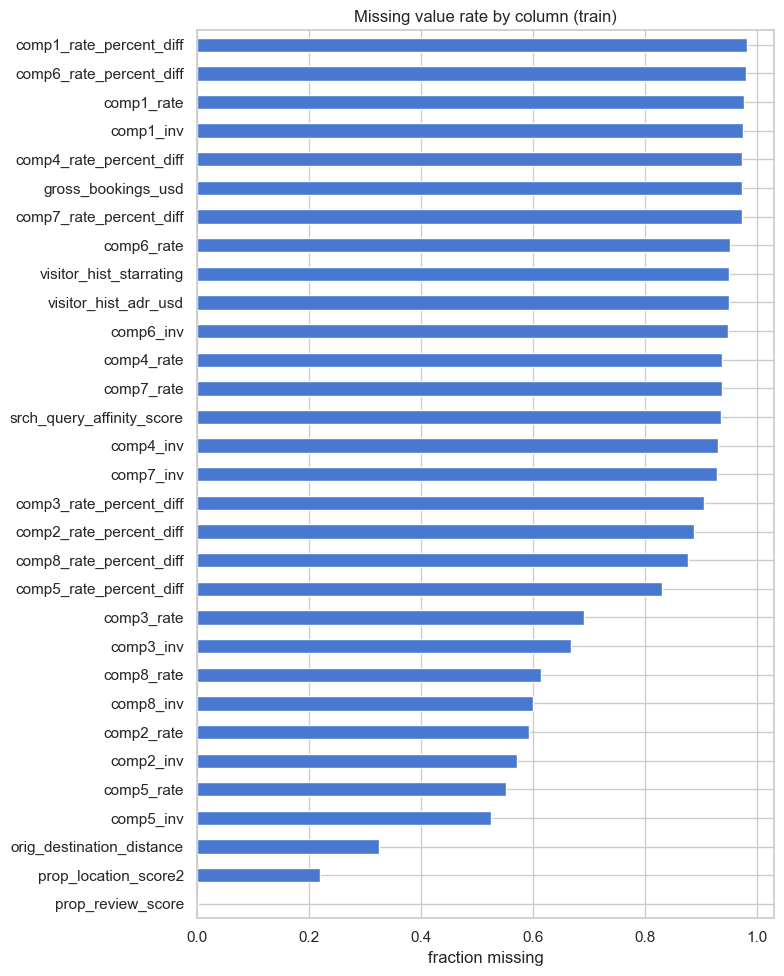

In [14]:
fig, ax = plt.subplots(figsize=(8, max(4, 0.32 * len(miss))))
miss.iloc[::-1].plot.barh(ax=ax, color="#4878d0")
ax.set_xlabel("fraction missing")
ax.set_title("Missing value rate by column (train)")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_missingness.png", dpi=110)
plt.show()

31 of 54 columns have missing values. The pattern splits cleanly into three groups:

1. **Competitor block (`comp1_*` to `comp8_*`)**: each set of three has between 83% and 98% missing. These are only filled when Expedia had a competitor quote available. Imputing them with anything other than zero is risky because zero already has a meaning in the spec ("no difference"); I will most likely keep them as NaN and let LightGBM split on missingness.
2. **Visitor history**: `visitor_hist_starrating` and `visitor_hist_adr_usd` are missing 95% of the time. That is the share of users with no prior Expedia booking. A `has_visitor_history` flag is the cheapest way to surface this signal.
3. **Other**: `srch_query_affinity_score` (94%) and `orig_destination_distance` (32%, not in the top-20 print) are sparser than I expected. `prop_review_score` is 0.15% missing, basically full.

## Cardinalities of categorical-ish columns

The IDs need a strategy. One-hot is unrealistic if cardinality is large.

In [15]:
cat_candidates = [
    "site_id",
    "visitor_location_country_id",
    "prop_country_id",
    "prop_id",
    "srch_destination_id",
]
for col in cat_candidates:
    if col in train.columns:
        n_train = train[col].nunique()
        n_test = test[col].nunique() if col in test.columns else None
        overlap = (
            train[col].isin(set(test[col].unique())).mean()
            if col in test.columns
            else None
        )
        print(f"{col}: train uniques={n_train:,}, test uniques={n_test}, "
              f"share-of-train-rows-with-id-also-in-test={overlap}")

site_id: train uniques=34, test uniques=34, share-of-train-rows-with-id-also-in-test=1.0
visitor_location_country_id: train uniques=210, test uniques=210, share-of-train-rows-with-id-also-in-test=0.9999302186797334
prop_country_id: train uniques=172, test uniques=167, share-of-train-rows-with-id-also-in-test=0.9999832605503407
prop_id: train uniques=129,113, test uniques=129438, share-of-train-rows-with-id-also-in-test=0.9974001416197777
srch_destination_id: train uniques=18,127, test uniques=18049, share-of-train-rows-with-id-also-in-test=0.9709604834030373


Two clean buckets:

- **Small ID columns**: `site_id` (34), country IDs (~200). One-hot encoding is fine here.
- **Large ID columns**: `prop_id` (129k), `srch_destination_id` (18k). Far too large for one-hot. Two reasonable options: pass them as native categorical to LightGBM, or build target-style aggregations (historical click rate, booking rate, etc) keyed on these IDs.

Test coverage is high: 99.7% of test prop_ids are seen in train, and 97.1% of test rows have a `srch_destination_id` that train has seen. So target encoding is feasible without too much new-key fallback work.

## Price sanity

Hotel prices are notorious for outliers (per-night vs total stay, different currencies stored as USD). A quick look on a sampled subset.

In [16]:
price_sample = train["price_usd"].sample(500_000, random_state=42)
print(price_sample.describe(percentiles=[0.5, 0.9, 0.99, 0.999]))

count    5.000000e+05
mean     2.566835e+02
std      1.277417e+04
min      0.000000e+00
50%      1.220000e+02
90%      2.772000e+02
99%      6.000000e+02
99.9%    2.050006e+03
max      4.339792e+06
Name: price_usd, dtype: float64


Median price is $122, the 90th percentile is $277, but the 99.9th percentile jumps to $2,050 and the maximum is $4.3M. Either some rows are stored as the total stay cost or in a non-USD currency that was not converted, or there is a handful of bogus listings. log1p will tame all of this; the histogram next confirms that.

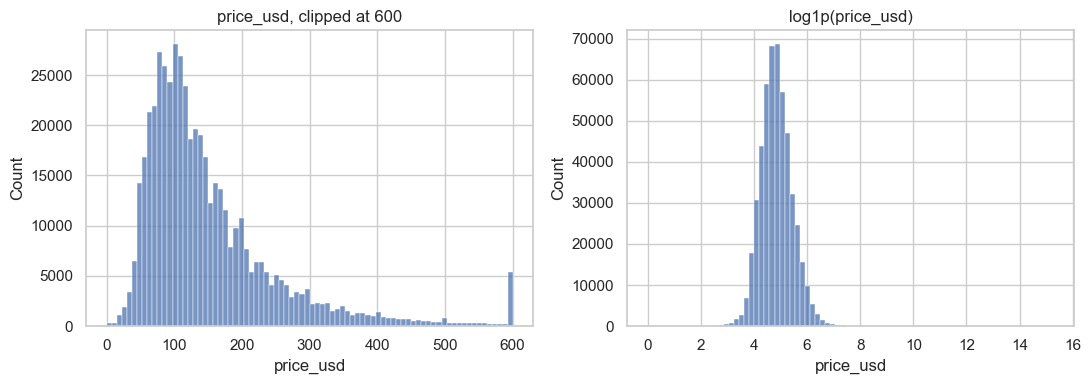

13604

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(price_sample.clip(upper=600), bins=80, ax=axes[0])
axes[0].set_title("price_usd, clipped at 600")
sns.histplot(np.log1p(price_sample), bins=80, ax=axes[1])
axes[1].set_title("log1p(price_usd)")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_price.png", dpi=110)
plt.show()
del price_sample
gc.collect()

Left panel: clipped at 600, the bulk lies between 50 and 250 with a right skew. The bar at 600 is the clipping artefact; it is roughly 5,500 rows pushed into the last bin. Right panel: `log1p(price)` is approximately Gaussian centred near 4.5 (which is around 90 USD), with a thin tail stretching to 16 (which is the 4 million USD outlier zone). I will use `log1p(price_usd)` rather than the raw price for the model.

## Star rating, location score, review score versus booking

Quick sanity: do the obvious quality features actually correlate with bookings?

In [18]:
quality_cols = [
    "prop_starrating",
    "prop_review_score",
    "prop_location_score1",
    "prop_location_score2",
    "promotion_flag",
    "price_usd",
]
sample = train[quality_cols + ["booking_bool", "click_bool"]].sample(
    1_000_000, random_state=42
)
corr = sample.corr(numeric_only=True)["booking_bool"].drop(["booking_bool", "click_bool"])
corr = corr.sort_values()
print(corr)

prop_location_score1   -0.002953
price_usd               0.000602
prop_starrating         0.020947
prop_review_score       0.026788
promotion_flag          0.035785
prop_location_score2    0.066213
Name: booking_bool, dtype: float64


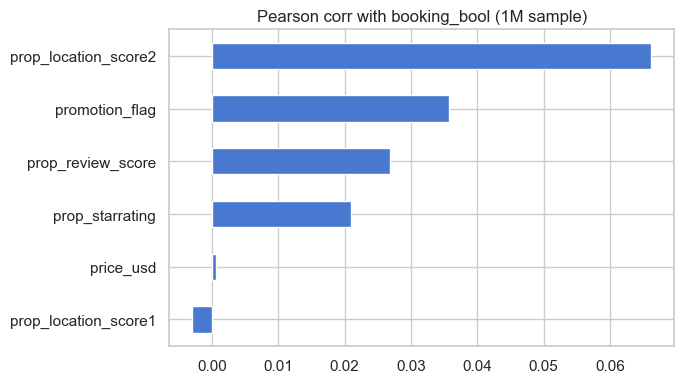

7904

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
corr.plot.barh(ax=ax, color="#4878d0")
ax.set_title("Pearson corr with booking_bool (1M sample)")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_corr_booking.png", dpi=110)
plt.show()
del sample, corr
gc.collect()

All of these absolute correlations are tiny (the largest is 0.066). That is expected because `booking_bool` is 97% zeros and Pearson on a heavily imbalanced 0/1 target is bounded above by something close to the positive rate. What matters is the ordering:

- `prop_location_score2` is the strongest single feature here, by a clear margin. That matches what I expected; it is supposed to be a derived location score and Expedia presumably tunes it for ranking.
- `promotion_flag`, `prop_review_score`, `prop_starrating` follow.
- `price_usd` is essentially zero. That looks wrong at first, but it makes sense: a $300 hotel in Paris can outperform a $300 hotel in Detroit, and without conditioning on the search the global correlation washes out. This tells me that price-based features only become useful relative to the other hotels in the same query. That is a strong hint to engineer a `price_rank_within_srch` feature in notebook 03.
- `prop_location_score1` is essentially zero. Score 2 dominates score 1.

## Position and the random_bool flag

Some rows are flagged `random_bool=1`, which the documentation says means the results were shuffled rather than ranked by Expedia's own algorithm. That is a clean way to inspect whether high position causes more bookings, or whether better hotels are placed higher.

random_bool distribution at row level:
random_bool
0    0.7041
1    0.2959
Name: proportion, dtype: float64


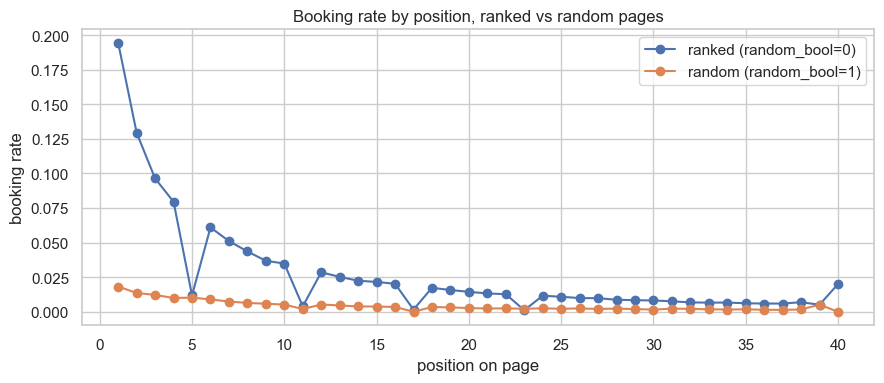

In [20]:
print("random_bool distribution at row level:")
print(train["random_bool"].value_counts(normalize=True))

ranked_book = train.loc[train["random_bool"] == 0].groupby("position")["booking_bool"].mean()
random_book = train.loc[train["random_bool"] == 1].groupby("position")["booking_bool"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ranked_book.head(40).plot(ax=ax, label="ranked (random_bool=0)", marker="o")
random_book.head(40).plot(ax=ax, label="random (random_bool=1)", marker="o")
ax.set_xlabel("position on page")
ax.set_ylabel("booking rate")
ax.set_title("Booking rate by position, ranked vs random pages")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_position_bias.png", dpi=110)
plt.show()

Two things jump out of this plot:

1. **Position bias is real but mild.** On random pages, the booking rate starts near 1.8% at position 1 and decays gently to about 0.3% by position 30. Users do not totally ignore the lower positions. So the much steeper decay we see on ranked pages, from 19% at position 1 down to 1.3% by position 5, is mostly "Expedia's own ranker has put the actually-best hotels on top" rather than "users only look at the top".
2. **Page boundaries matter.** On ranked pages, booking rate drops at position 5 then bumps back up at position 6, drops again at 11, bumps at 12, and so on. These look like UI page breaks rather than a smooth decay. If we ever try to use `position` as a feature (which we cannot at predict time anyway) we would have to be careful with these.

The practical implication for the model: there is information in `random_bool=1` rows about pure user preference (decoupled from Expedia's ranker), but they are only 30% of rows. We may want to weight or handle them separately. I will revisit that in notebook 04.

## Visitor-history columns

`visitor_hist_starrating` and `visitor_hist_adr_usd` describe the user's prior bookings. From the missingness chart they look mostly empty, but when they are present, do they actually relate to the price the user ends up booking?

In [21]:
has_hist = train["visitor_hist_adr_usd"].notna()
print(f"share of rows with visitor history: {has_hist.mean():.4f}")

book_rate_hist = train.loc[has_hist, "booking_bool"].mean()
book_rate_no_hist = train.loc[~has_hist, "booking_bool"].mean()
print(f"book rate, with history:    {book_rate_hist:.4f}")
print(f"book rate, without history: {book_rate_no_hist:.4f}")

share of rows with visitor history: 0.0510
book rate, with history:    0.0361
book rate, without history: 0.0275


5.1% of rows have visitor history. Those rows book at 3.6% versus 2.8% for rows without. The lift is small but consistent: returning users are slightly more likely to book. That justifies a `has_visitor_history` indicator feature. The actual `visitor_hist_*` numeric values are probably most useful when compared against the current row's price and star, which is something I will try in notebook 03.

## Wrap-up

Take-aways feeding into the rest of the project:

1. The data is grouped by `srch_id` (199,795 searches in train, mostly 32 hotels per page). Splits and CV must respect groups.
2. Targets: relevance = 5 (booked, 138k rows) / 1 (click-only, 83k rows) / 0 (rest). NDCG@5 with `label_gain=[0,1,5]` is the natural objective.
3. Train-only columns to drop at predict time: `position`, `click_bool`, `booking_bool`, `gross_bookings_usd`.
4. Heavy missingness in competitor block and visitor history; LightGBM-native NaN handling plus a `has_visitor_history` flag should be the default.
5. `price_usd` has 6+ orders-of-magnitude outliers; `log1p` flattens that completely.
6. `prop_location_score2` is the single strongest correlated feature; price-based features only become useful once relativised within a search.
7. Position bias is real but page-aware. Random-page booking rates are flat.
8. Categorical handling: small IDs (site, country) can be one-hot, large IDs (`prop_id`, `srch_destination_id`) need native categorical or target encoding.

In [22]:
del train, test
gc.collect()
print(f"final RSS after cleanup: {rss_gb():.2f} GB")

final RSS after cleanup: 3.57 GB
